## ***Attrition Prediction of Employess***

**Employee Attrition Prediction is the process of using employee data to identify patterns and predict which employees are likely to leave an organization. It is a part of HR Analytics, which helps organizations make data-driven decisions to improve employee retention and overall workforce performance.**

**Why HR Analytics Matters?**

**Organizations collect large amounts of employee data, but raw data alone provides little value. By analyzing and interpreting this data, companies can gain meaningful insights and answer important questions such as:**

**What factors contribute to employee turnover?**\
**How long does it take to hire and onboard employees?**\
**Which employees are at higher risk of leaving?**\
**Are training and development programs improving performance?**

In [2]:
# importing libraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### **Loading data**

In [3]:
data = pd.read_csv("IBM_HR_Data_new.csv")
df = data.copy()
df.head()

C:\Users\laptop\AppData\Local\Temp\ipykernel_3224\3693919213.py:1: DtypeWarning: Columns (5,8,10) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("IBM_HR_Data_new.csv")


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Employee Source
0,41.0,Voluntary Resignation,Travel_Rarely,1102.0,Sales,1,2.0,Life Sciences,1,1,...,80.0,0.0,8.0,0.0,1.0,6.0,4.0,0.0,5.0,Referral
1,41.0,Voluntary Resignation,Travel_Rarely,1102.0,Sales,1,2.0,Life Sciences,1,1,...,80.0,0.0,8.0,0.0,1.0,6.0,4.0,0.0,5.0,Referral
2,41.0,Voluntary Resignation,Travel_Rarely,1102.0,Sales,1,2.0,Life Sciences,1,7,...,80.0,0.0,8.0,0.0,1.0,6.0,4.0,0.0,5.0,Referral
3,41.0,Voluntary Resignation,Travel_Rarely,1102.0,Sales,1,2.0,Life Sciences,1,8,...,80.0,0.0,8.0,0.0,1.0,6.0,4.0,0.0,5.0,Referral
4,41.0,Voluntary Resignation,Travel_Rarely,1102.0,Sales,1,2.0,Life Sciences,1,9,...,80.0,0.0,8.0,0.0,1.0,6.0,4.0,0.0,5.0,Referral


### **Initial Inspection of Data**

In [4]:
# info about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23436 entries, 0 to 23435
Data columns (total 37 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       23433 non-null  float64
 1   Attrition                 23423 non-null  object 
 2   BusinessTravel            23428 non-null  object 
 3   DailyRate                 23424 non-null  float64
 4   Department                23425 non-null  object 
 5   DistanceFromHome          23427 non-null  object 
 6   Education                 23424 non-null  float64
 7   EducationField            23427 non-null  object 
 8   EmployeeCount             23431 non-null  object 
 9   EmployeeNumber            23435 non-null  object 
 10  Application ID            23433 non-null  object 
 11  EnvironmentSatisfaction   23427 non-null  float64
 12  Gender                    23426 non-null  object 
 13  HourlyRate                23427 non-null  object 
 14  JobInv

In [5]:
# checking shape of the dataset
df.shape

(23436, 37)

In [6]:
# column names and their index
for i, col in enumerate(df.columns):
    print(i, col)

0 Age
1 Attrition
2 BusinessTravel
3 DailyRate
4 Department
5 DistanceFromHome
6 Education
7 EducationField
8 EmployeeCount
9 EmployeeNumber
10 Application ID
11 EnvironmentSatisfaction
12 Gender
13 HourlyRate
14 JobInvolvement
15 JobLevel
16 JobRole
17 JobSatisfaction
18 MaritalStatus
19 MonthlyIncome
20 MonthlyRate
21 NumCompaniesWorked
22 Over18
23 OverTime
24 PercentSalaryHike
25 PerformanceRating
26 RelationshipSatisfaction
27 StandardHours
28 StockOptionLevel
29 TotalWorkingYears
30 TrainingTimesLastYear
31 WorkLifeBalance
32 YearsAtCompany
33 YearsInCurrentRole
34 YearsSinceLastPromotion
35 YearsWithCurrManager
36 Employee Source


In [7]:
df.sample(5)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Employee Source
12206,50.0,Current employee,Travel_Rarely,1207.0,Research & Development,28,1.0,Medical,1,15417,...,80.0,1.0,33.0,2.0,3.0,33.0,9.0,0.0,10.0,Seek
4309,30.0,Current employee,Travel_Rarely,317.0,Research & Development,2,3.0,Life Sciences,1,6635,...,80.0,0.0,11.0,2.0,3.0,5.0,4.0,0.0,2.0,Company Website
10134,27.0,Current employee,Travel_Frequently,994.0,Sales,8,3.0,Marketing,1,828,...,80.0,0.0,9.0,0.0,3.0,9.0,8.0,1.0,7.0,LinkedIn
20614,52.0,Voluntary Resignation,Travel_Rarely,1030.0,Sales,5.0,3.0,Life Sciences,1,15174,...,80.0,0.0,10.0,2.0,2.0,8.0,7.0,7.0,7.0,Jora
5051,31.0,Voluntary Resignation,Travel_Frequently,1445.0,Research & Development,1,5.0,Life Sciences,1,16546,...,80.0,0.0,10.0,2.0,3.0,10.0,8.0,4.0,7.0,GlassDoor


### **Data Cleaning and Preprocessing**

In [8]:
# checking for missing values
missing_percentage = (df.isnull().sum() / len(df)) * 100
print(missing_percentage)

Age                         0.012801
Attrition                   0.055470
BusinessTravel              0.034136
DailyRate                   0.051203
Department                  0.046936
DistanceFromHome            0.038402
Education                   0.051203
EducationField              0.038402
EmployeeCount               0.021335
EmployeeNumber              0.004267
Application ID              0.012801
EnvironmentSatisfaction     0.038402
Gender                      0.042669
HourlyRate                  0.038402
JobInvolvement              0.038402
JobLevel                    0.029869
JobRole                     0.038402
JobSatisfaction             0.038402
MaritalStatus               0.046936
MonthlyIncome               0.055470
MonthlyRate                 0.046936
NumCompaniesWorked          0.038402
Over18                      0.042669
OverTime                    0.051203
PercentSalaryHike           0.059737
PerformanceRating           0.042669
RelationshipSatisfaction    0.034136
S

In [9]:
# since missing values are less than 5% of the dataset dropping the rows with missing values
df = df.dropna()

In [ ]:
# check duplicate rows
duplicate_rows = df.duplicated().sum()
print("Duplicate Rows:", duplicate_rows)

In [12]:
# dropping duplicate rows since they are not needed for analysis
df = df.drop_duplicates()
print("Rows after dropping duplicates:", len(df))

Rows after dropping duplicates: 23190


In [13]:
# checking column data types
print(df.dtypes)    

Age                         float64
Attrition                    object
BusinessTravel               object
DailyRate                   float64
Department                   object
DistanceFromHome             object
Education                   float64
EducationField               object
EmployeeCount                object
EmployeeNumber               object
Application ID               object
EnvironmentSatisfaction     float64
Gender                       object
HourlyRate                   object
JobInvolvement              float64
JobLevel                    float64
JobRole                      object
JobSatisfaction              object
MaritalStatus                object
MonthlyIncome                object
MonthlyRate                 float64
NumCompaniesWorked          float64
Over18                       object
OverTime                     object
PercentSalaryHike            object
PerformanceRating           float64
RelationshipSatisfaction    float64
StandardHours               

In [95]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
dtype: int64

In [14]:
# changing data types of columns to numeric data type
numeric_cols = ['DistanceFromHome','EmployeeCount','EmployeeNumber','HourlyRate','JobSatisfaction','MonthlyIncome','PercentSalaryHike']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [15]:
# dropping columns that are not useful for analysis
drop_cols = ['EmployeeCount','EmployeeNumber','Application ID','Over18','StandardHours','Employee Source',]
df=df.drop(columns=drop_cols)

In [16]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,23190.0,36.922941,9.116307,18.0,30.0,36.0,43.0,60.0
DailyRate,23190.0,802.246313,403.207375,102.0,465.0,802.0,1157.0,1499.0
DistanceFromHome,23190.0,9.188486,8.098394,1.0,2.0,7.0,14.0,29.0
Education,23190.0,2.908754,1.024915,1.0,2.0,3.0,4.0,5.0
EnvironmentSatisfaction,23190.0,2.719879,1.094924,1.0,2.0,3.0,4.0,4.0
HourlyRate,23190.0,65.857740,20.335312,30.0,48.0,66.0,83.0,100.0
JobInvolvement,23190.0,2.730574,0.710093,1.0,2.0,3.0,3.0,4.0
JobLevel,23190.0,2.065373,1.105947,1.0,1.0,2.0,3.0,5.0
JobSatisfaction,23190.0,2.727771,1.101444,1.0,2.0,3.0,4.0,4.0
MonthlyIncome,23190.0,6507.905520,4706.369675,1009.0,2911.0,4936.0,8380.0,19999.0


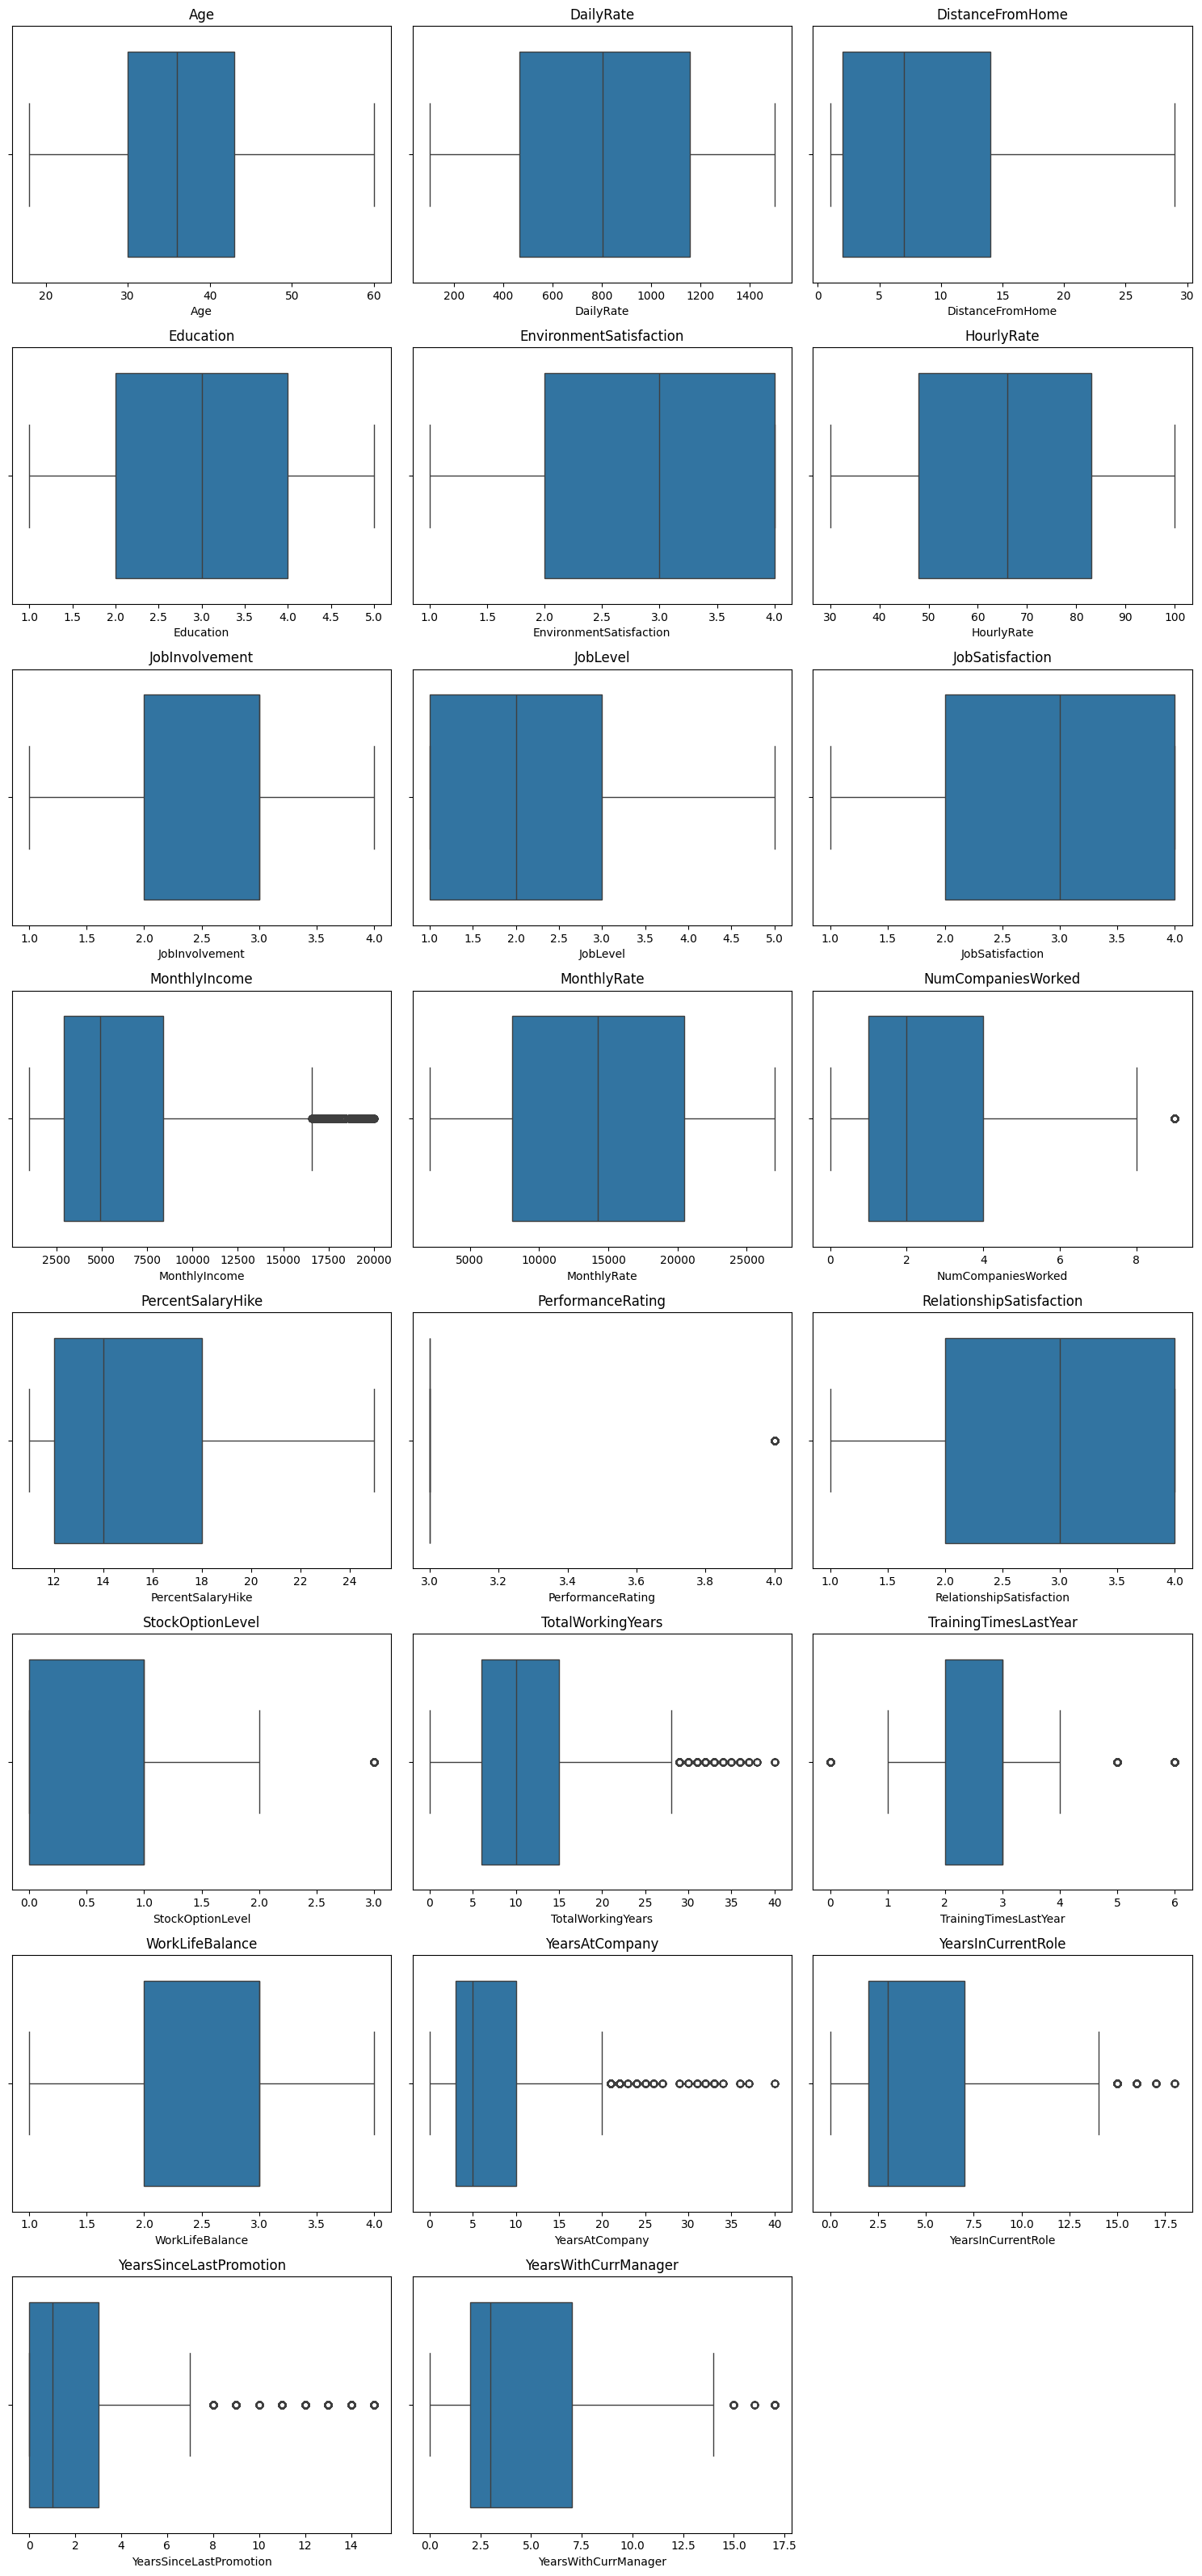

In [17]:
# checking for outliers using boxplots for numeric columns

num_cols = df.select_dtypes(include=['int64', 'float64']).columns
n = len(num_cols)

import math
n_cols = 3
n_rows = math.ceil(n / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

# boxplots
for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)

# removing empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### **Exploratory Data Analysis**

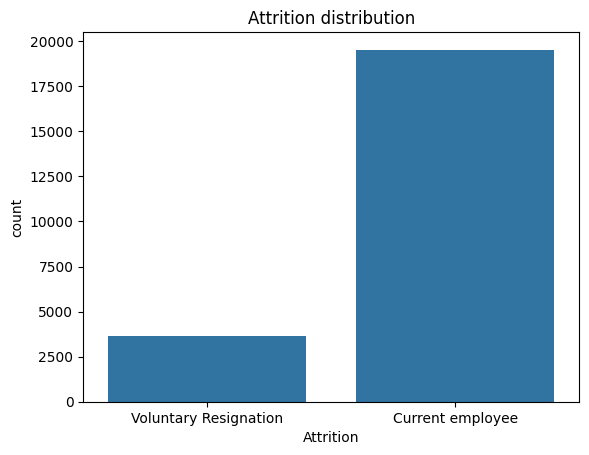

In [18]:
# checking distribution of target variable
sns.countplot(x='Attrition', data=df)
plt.title("Attrition distribution")
plt.show()

In [19]:
df['Attrition'].value_counts(normalize=True)*100

Attrition
Current employee         84.204398
Voluntary Resignation    15.795602
Name: proportion, dtype: float64

**The dataset is imbalanced. `Approximately 84% of employees stayed while 16% left the organization`. Therefore, accuracy alone may not be an appropriate evaluation metric.**

#### **Are employees mostly young or experienced?**

Text(0.5, 1.0, 'age distribution')

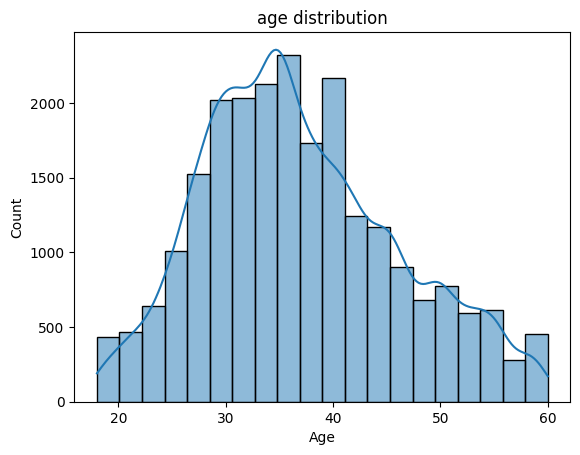

In [20]:
# age distribution
sns.histplot(df['Age'], bins=20, kde=True)
plt.title("age distribution")

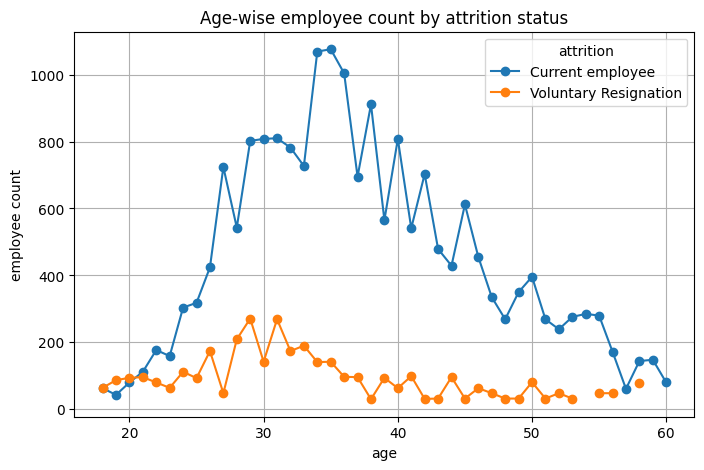

In [21]:
# age wise employee count by attrition status

age_att = df.groupby(['Age', 'Attrition']).size().unstack()
age_att.plot(marker='o', figsize=(8, 5))

plt.title('Age-wise employee count by attrition status')
plt.xlabel('age')
plt.ylabel('employee count')
plt.legend(title='attrition')
plt.grid(True)


**It shows that employee attrition is highest among individuals `aged 28–32 years`. As age increases, the attrition rate gradually declines**\
**After the age of 35, the attrition trend begins to `stabilize`**

#### **Do lower-paid employees leave more often?**

Text(0, 0.5, 'monthly income')

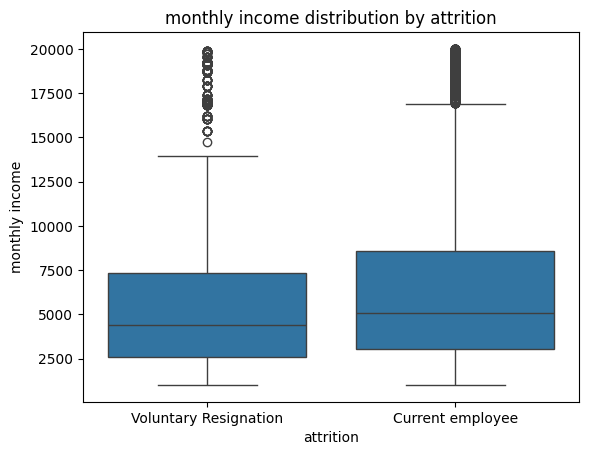

In [22]:
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome')
plt.title('monthly income distribution by attrition')
plt.xlabel('attrition')
plt.ylabel('monthly income')


**The boxplot showed that employees who left had a `slightly lower median monthly income`. However, the large overlap between the two groups indicated that `salary alone could not explain attrition`,this suggested that other variables satisfaction should also be investigated before drawing conclusions**

#### **Does low job satisfaction increase attrition?**

Text(0, 0.5, 'attrition rate (%)')

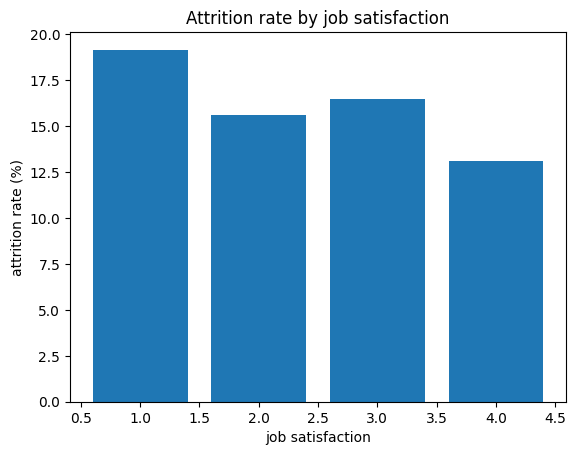

In [23]:
job_satis_rate = pd.crosstab(df['JobSatisfaction'],df['Attrition'],normalize='index') * 100
plt.bar(job_satis_rate.index,job_satis_rate['Voluntary Resignation'])

plt.title('Attrition rate by job satisfaction')
plt.xlabel('job satisfaction')
plt.ylabel('attrition rate (%)')

**I analyzed attrition rates across Job Satisfaction levels and found that employees with the lowest satisfaction had the highest attrition rate, about `19%`, while employees with very high satisfaction had the lowest attrition rate, around `13%`. This indicated that job satisfaction is an important predictor of attrition. However, since the `pattern wasn't perfectly linear`, I concluded that attrition is driven by multiple interacting factors rather than satisfaction alone**

#### **Are employees working overtime more likely to leave?**

Text(0, 0.5, 'attrition rate (%)')

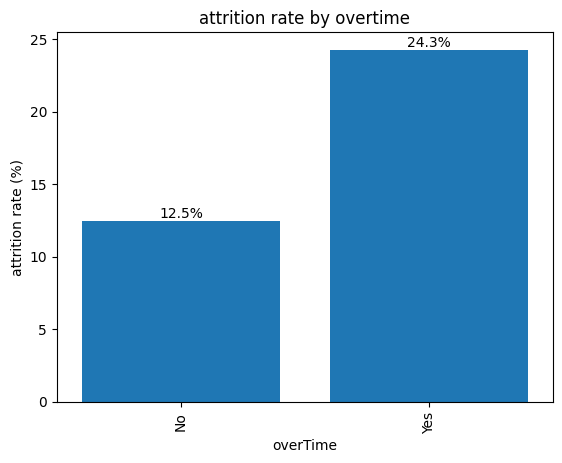

In [24]:
attrition_rate = pd.crosstab(df['OverTime'], df['Attrition'], normalize='index')['Voluntary Resignation'] * 100
bars = plt.bar(attrition_rate.index, attrition_rate.values)

attrition_rate.plot(kind='bar')
plt.bar_label(bars, fmt='%.1f%%')
plt.title('attrition rate by overtime')
plt.xlabel('overTime')
plt.ylabel('attrition rate (%)')

**One of the strongest findings was the impact of overtime on attrition. Employees working overtime had an `attrition rate of 24.3%, compared to 12.5% for those who did not`. This means overtime employees were almost `twice` as likely to leave the organization. From a business perspective, this suggests that `workload` and `work-life balance` are critical areas for HR intervention.**

#### **Which department has the highest turnover?**

(0.0, 23.371598639455783)

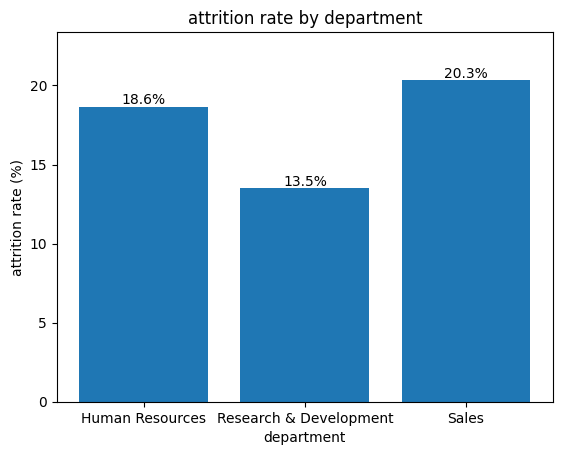

In [25]:
dept_rate = pd.crosstab(df['Department'], df['Attrition'], normalize='index')['Voluntary Resignation'] * 100
bars = plt.bar(dept_rate.index, dept_rate.values)

plt.bar_label(bars, fmt='%.1f%%')
plt.title('attrition rate by department')
plt.xlabel('department')
plt.ylabel('attrition rate (%)')
plt.ylim(0, dept_rate.max() * 1.15)

**Sales had the highest attrition rate at about `20.3%`, while Research & Development had the lowest at `13.5%`. This indicated that employee turnover was influenced by departmental factors, suggesting that HR interventions should be customized rather than applying the same retention strategy across the entire organization**

#### **Are employees with poor work-life balance more likely to leave?**

Text(0, 0.5, 'attrition rate (%)')

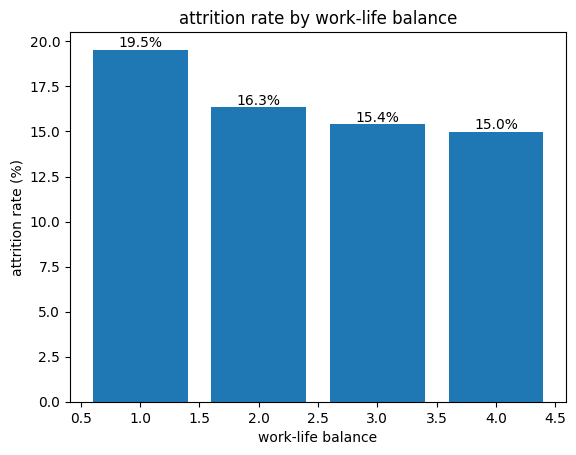

In [26]:
wlb_rate = (pd.crosstab(df['WorkLifeBalance'], df['Attrition'], normalize='index')['Voluntary Resignation'] * 100)
bars = plt.bar(wlb_rate.index, wlb_rate.values)

plt.bar_label(bars, fmt='%.1f%%')
plt.title('attrition rate by work-life balance')
plt.xlabel('work-life balance')
plt.ylabel('attrition rate (%)')

**I observed that employees with poor work-life balance had the highest attrition rate, around `19.5%`, while employees with the best work-life balance had the `lowest attrition rate`, approximately `15%`. This suggested a  `negative relationship` between work-life balance and attrition. However, the difference was moderate compared to overtime, indicating that work-life balance is an important but not the strongest driver of employee turnover**

#### **Do employees leave early in their tenure or after many years?**

Text(0, 0.5, 'attrition rate (%)')

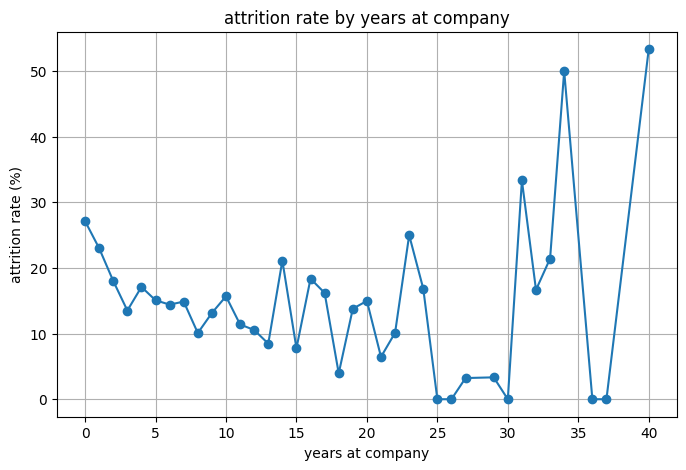

In [27]:

years_rate = (pd.crosstab(df['YearsAtCompany'], df['Attrition'], normalize='index')['Voluntary Resignation'] * 100)
plt.figure(figsize=(8, 5))
plt.grid(True)
plt.plot(years_rate.index, years_rate.values, marker='o')
plt.title('attrition rate by years at company')
plt.xlabel('years at company')
plt.ylabel('attrition rate (%)')

**I found that attrition was highest among employees in their `early years` with the company and generally `declined` as tenure `increased`. There were some `large spikes` among employees with over 30 years of service, but I recognized that these groups had `very few observations`, making the estimates unstable. Therefore, I concluded that early-tenure employees represent the most important segment for retention efforts.**

#### **Does a lack of promotions increase employee attrition?**

Text(0, 0.5, 'Attrition Rate (%)')

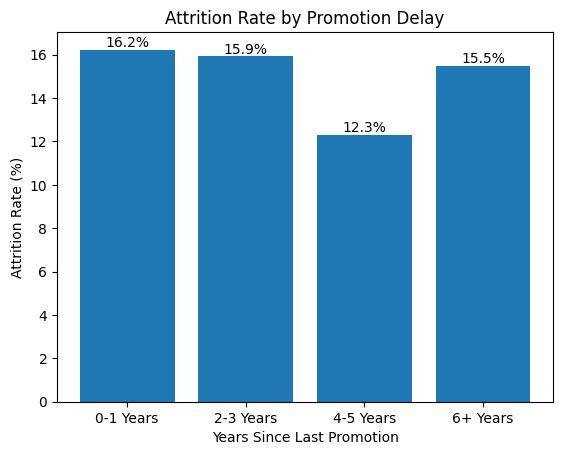

In [28]:
df['PromotionDelay'] = pd.cut(
    df['YearsSinceLastPromotion'],
    bins=[-1, 1, 3, 5, df['YearsSinceLastPromotion'].max()],
    labels=['0-1 Years', '2-3 Years', '4-5 Years', '6+ Years']
)

attrition_rate = (pd.crosstab(df['PromotionDelay'], df['Attrition'], normalize='index') ['Voluntary Resignation'] * 100)
bars = plt.bar(attrition_rate.index, attrition_rate.values)
plt.bar_label(bars, fmt='%.1f%%')

plt.title('Attrition Rate by Promotion Delay')
plt.xlabel('Years Since Last Promotion')
plt.ylabel('Attrition Rate (%)')

**Attrition rates ranged from 12.3% to 16.2% across promotion categories, with `no clear increasing trend`. Employees promoted within the previous year exhibited attrition rates similar to those who had experienced prolonged promotion delays. These findings indicate that career advancement opportunities alone may not sufficiently explain employee turnover and should be considered alongside other organizational factors.**

### **Feature Scaling and Encoding**

In [29]:
# uniquie values in each categorical column
for col in df.columns:
    if df[col].dtype == 'object':
        unique_values = df[col].unique()
        print(f"{col}: {unique_values}\n")  

Attrition: ['Voluntary Resignation' 'Current employee']

BusinessTravel: ['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']

Department: ['Sales' 'Research & Development' 'Human Resources']

EducationField: ['Life Sciences' 'Technical Degree' 'Medical' 'Marketing' 'Other'
 'Human Resources' 'Test']

Gender: ['Female' 'Male']

JobRole: ['Sales Executive' 'Manager' 'Research Director' 'Sales Representative'
 'Laboratory Technician' 'Research Scientist' 'Manufacturing Director'
 'Healthcare Representative' 'Human Resources']

MaritalStatus: ['Single' 'Divorced' 'Married']

OverTime: ['Yes' 'No']



In [30]:
df.head(5 )

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,PromotionDelay
0,41.0,Voluntary Resignation,Travel_Rarely,1102.0,Sales,1.0,2.0,Life Sciences,2.0,Female,...,1.0,0.0,8.0,0.0,1.0,6.0,4.0,0.0,5.0,0-1 Years
1,41.0,Voluntary Resignation,Travel_Rarely,1102.0,Sales,1.0,2.0,Life Sciences,2.0,Female,...,1.0,0.0,8.0,0.0,1.0,6.0,4.0,0.0,5.0,0-1 Years
2,41.0,Voluntary Resignation,Travel_Rarely,1102.0,Sales,1.0,2.0,Life Sciences,2.0,Female,...,1.0,0.0,8.0,0.0,1.0,6.0,4.0,0.0,5.0,0-1 Years
3,41.0,Voluntary Resignation,Travel_Rarely,1102.0,Sales,1.0,2.0,Life Sciences,2.0,Female,...,1.0,0.0,8.0,0.0,1.0,6.0,4.0,0.0,5.0,0-1 Years
4,41.0,Voluntary Resignation,Travel_Rarely,1102.0,Sales,1.0,2.0,Life Sciences,2.0,Female,...,1.0,0.0,8.0,0.0,1.0,6.0,4.0,0.0,5.0,0-1 Years


In [31]:
# encoding the coulms 

# dropping promotion delay column as it is not useful for prediction
df = df.drop('PromotionDelay', axis=1)
df_encoded = df.copy()

# target variable encoding
df_encoded['Attrition'] = df_encoded['Attrition'].map({ 'Current employee': 0,'Voluntary Resignation': 1})

# binary variables
df_encoded['Gender'] = df_encoded['Gender'].map({'Female': 0,'Male': 1})

# overtime encoding
df_encoded['OverTime'] = df_encoded['OverTime'].map({'No': 0,'Yes': 1})

# nominal variables
nominal_cols = ['BusinessTravel','Department','EducationField', 'JobRole','MaritalStatus']
df_encoded = pd.get_dummies(df_encoded,columns=nominal_cols,drop_first=True,dtype=int)


print("Shape after encoding:", df_encoded.shape)

Shape after encoding: (23190, 46)


In [32]:
df_encoded.head()
print(df.shape)

(23190, 31)


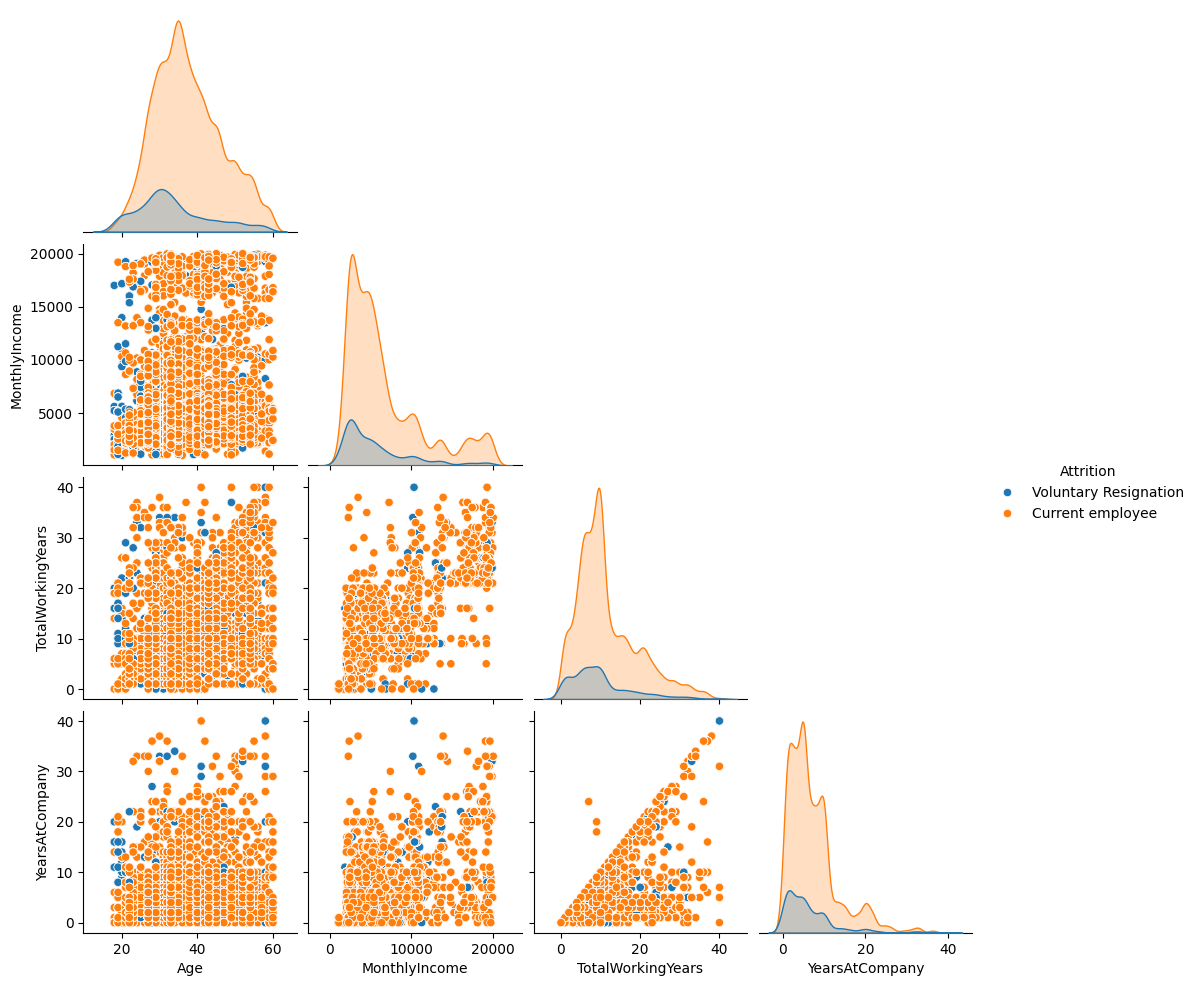

In [33]:
# pairplot for the  columns to visualize the relationship between the features and the target variable
cols = ['Age','MonthlyIncome','TotalWorkingYears','YearsAtCompany','Attrition']

sns.pairplot(df[cols], hue='Attrition', corner=True)

Text(0.5, 1.0, 'Correlation Matrix')

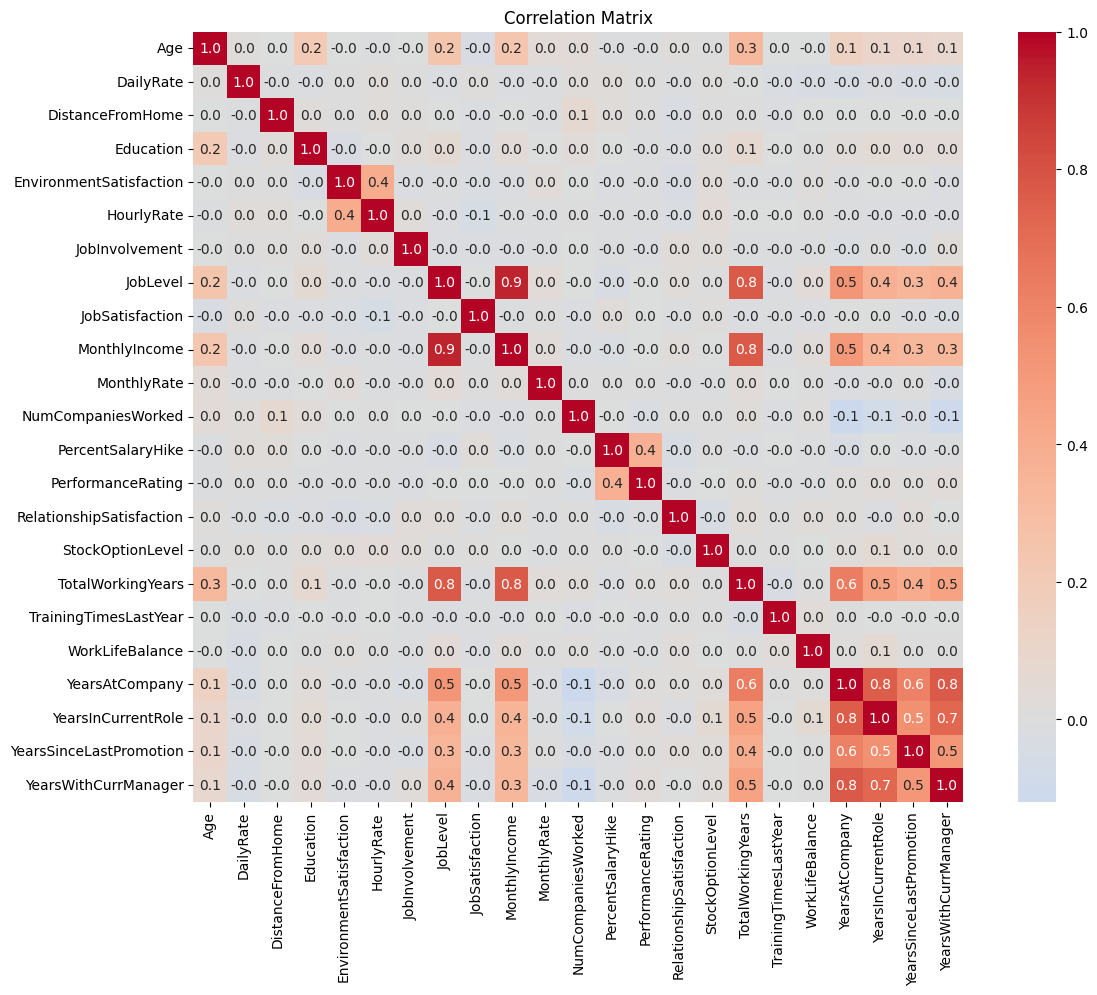

In [34]:
# correlation heatmap
corr = df.corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(corr,cmap='coolwarm',center=0,annot=True,fmt='.1f',square=True,)

plt.title('Correlation Matrix')


In [35]:
# splitting the dataset into training and testing sets and scaling continuous variables

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# features and target
X = df_encoded.drop('Attrition', axis=1)
y = df_encoded['Attrition']

# splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,stratify=y,random_state=42)

# scaling continuous variables
continuous_cols = ['Age','DailyRate','DistanceFromHome','HourlyRate','MonthlyIncome','MonthlyRate','NumCompaniesWorked','PercentSalaryHike','TotalWorkingYears','TrainingTimesLastYear','YearsAtCompany','YearsInCurrentRole','YearsSinceLastPromotion','YearsWithCurrManager']

scaler = StandardScaler()

# creating copies of the training and testing sets to avoid modifying the original data
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# scale continuous variables
X_train_scaled[continuous_cols] = scaler.fit_transform( X_train[continuous_cols])
X_test_scaled[continuous_cols] = scaler.transform( X_test[continuous_cols])

print("Scaling completed ")
print("\nTraining shape:", X_train_scaled.shape)
print("Testing shape:", X_test_scaled.shape)


Scaling completed 

Training shape: (18552, 45)
Testing shape: (4638, 45)


In [36]:
X_train_scaled.head()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
17201,0.780431,-1.487920,2.446512,4.0,4.0,1,-1.660157,3.0,2.0,4,...,0,0,0,0,0,1,0,0,0,1
5996,-1.857468,-0.744248,-0.882152,3.0,3.0,1,0.747584,3.0,3.0,4,...,0,0,0,1,0,0,0,0,0,1
4990,-0.648431,-1.222677,2.446512,2.0,3.0,0,0.501896,2.0,1.0,2,...,0,1,0,0,0,0,0,0,1,0
12181,1.439905,0.133286,-1.005436,4.0,3.0,0,0.501896,3.0,2.0,3,...,0,0,0,0,0,0,1,0,1,0
17902,0.890343,0.321683,-0.019165,3.0,3.0,1,0.108796,4.0,2.0,3,...,0,0,0,1,0,0,0,0,0,0


### **Logistics Regression**

cross validation scores: [0.67259499 0.6734034  0.68948787 0.67520216 0.68679245]
Mean CV score: 0.6794961725938984
accuracy : 0.6888745148771022
precision: 0.2978359908883827
recall   : 0.713506139154161
F1 score : 0.420249096022499
classification Report:
              precision    recall  f1-score   support

           0       0.93      0.68      0.79      3905
           1       0.30      0.71      0.42       733

    accuracy                           0.69      4638
   macro avg       0.61      0.70      0.60      4638
weighted avg       0.83      0.69      0.73      4638



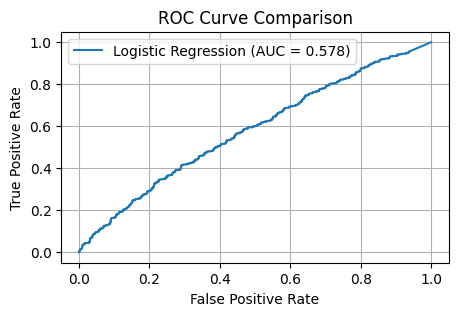

In [100]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(random_state=42,max_iter=1000,class_weight='balanced')
log_reg.fit(X_train_scaled, y_train)

# making predictions on the test set
y_pred_lr = log_reg.predict(X_test_scaled)
# cross valuation
from sklearn.model_selection import cross_val_score
scores = cross_val_score(log_reg, X_train_scaled, y_train, cv=5, scoring='accuracy')
print("cross validation scores:", scores)
print("Mean CV score:", scores.mean())  
# evaluating the model


from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,classification_report,roc_curve, auc

print("accuracy :", accuracy_score(y_test, y_pred_lr))
print("precision:", precision_score(y_test, y_pred_lr))
print("recall   :", recall_score(y_test, y_pred_lr))
print("F1 score :", f1_score(y_test, y_pred_lr))

# ROC curve 
lr_probs = log_reg.predict_proba(X_test)[:, 1]
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
lr_auc = auc(lr_fpr, lr_tpr)
plt.figure(figsize=(5, 3))

plt.plot(
    lr_fpr,
    lr_tpr,
    label=f'Logistic Regression (AUC = {lr_auc:.3f})'
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)

print("classification Report:")
print(classification_report(y_test, y_pred_lr))

In [80]:
# SMOTE + Logistic Regression Pipeline

# applying SMOTE to balance the dataset
from imblearn.over_sampling import SMOTE
X_train_smote, y_train_smote = SMOTE(random_state=42).fit_resample(X_train_scaled, y_train)
# model training using smote balanced dataset
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_smote, y_train_smote)

# predictions
y_pred_smote = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("accuracy :", accuracy_score(y_test, y_pred_smote))
print("precision:", precision_score(y_test, y_pred_smote))
print("recall   :", recall_score(y_test, y_pred_smote))
print("F1 Score :", f1_score(y_test, y_pred_smote))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

print("Classification Report:\n")
print(classification_report(y_test, y_pred_smote))


accuracy : 0.748814144027598
precision: 0.32965299684542587
recall   : 0.5702592087312415
F1 Score : 0.4177911044477761
ROC AUC  : 0.7477292378854549
Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.78      0.84      3905
           1       0.33      0.57      0.42       733

    accuracy                           0.75      4638
   macro avg       0.62      0.68      0.63      4638
weighted avg       0.82      0.75      0.77      4638



Random Forest Performance

Accuracy : 0.991
Precision: 0.973
Recall   : 0.969
F1 Score : 0.971


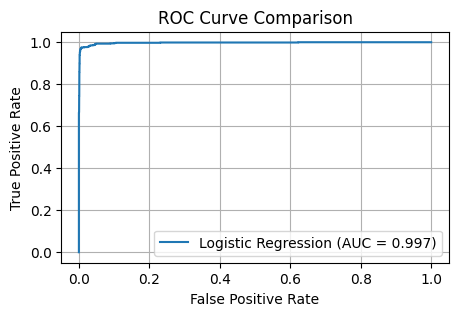

In [101]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

# ROC curve 
rf_probs = rf.predict_proba(X_test)[:, 1]
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
rf_auc = auc(rf_fpr, rf_tpr)
plt.figure(figsize=(5, 3))

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f'Logistic Regression (AUC = {rf_auc:.3f})'
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)
print("Random Forest Performance\n")

print("Accuracy :", round(accuracy_score(y_test, y_pred_rf), 3))
print("Precision:", round(precision_score(y_test, y_pred_rf), 3))
print("Recall   :", round(recall_score(y_test, y_pred_rf), 3))
print("F1 Score :", round(f1_score(y_test, y_pred_rf), 3))

In [88]:
train_pred = rf.predict(X_train)

print("train accuracy:", accuracy_score(y_train, train_pred))
print("test accuracy :", accuracy_score(y_test, y_pred_rf))
print("train recall :", recall_score(y_train, train_pred))
print("test recall  :", recall_score(y_test, y_pred_rf))
print("train F1 :", f1_score(y_train, train_pred))
print("test F1  :", f1_score(y_test, y_pred_rf))

train accuracy: 0.9934238896075894
test accuracy : 0.9907287623975851
train recall : 0.9815699658703072
test recall  : 0.9686221009549796
train F1 : 0.979230507320395
test F1  : 0.9706083390293917


In [ ]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

importance.sort_values(
    "Importance",
    ascending=False
).head(20)

,Feature,Importance
0,Age,0.122859
1,DailyRate,0.074987
10,MonthlyIncome,0.065676
2,DistanceFromHome,0.055577
6,HourlyRate,0.052963
11,MonthlyRate,0.047357
18,TotalWorkingYears,0.043827
13,OverTime,0.041667
14,PercentSalaryHike,0.035041
17,StockOptionLevel,0.033096


In [89]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3905
           1       0.97      0.97      0.97       733

    accuracy                           0.99      4638
   macro avg       0.98      0.98      0.98      4638
weighted avg       0.99      0.99      0.99      4638

[[3885   20]
 [  23  710]]


accuracy_score: 0.998
Precision: 0.995
Recall: 0.995
F1: 0.995


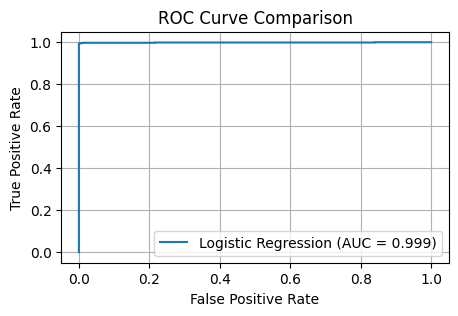

In [102]:
from xgboost import XGBClassifier

scale_pos_weight = (
    y_train.value_counts()[0] /
    y_train.value_counts()[1]
)

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train,y_train)

# making predictions and evaluating the model
y_pred_xgb = xgb.predict(X_test)
print('accuracy_score:', round(accuracy_score(y_test,y_pred_xgb),3))
print("Precision:", round(precision_score(y_test,y_pred_xgb),3))
print("Recall:", round(recall_score(y_test,y_pred_xgb),3))
print("F1:", round(f1_score(y_test,y_pred_xgb),3))

# ROC curve
# ROC curve 
xgb_probs = xgb.predict_proba(X_test)[:, 1]
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probs)
xgb_auc = auc(xgb_fpr, xgb_tpr)
plt.figure(figsize=(5, 3))

plt.plot(
    xgb_fpr,
    xgb_tpr,
    label=f'Logistic Regression (AUC = {xgb_auc:.3f})'
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)

## **Deploying the Model**

In [ ]:
import joblib
import streamlit as st

# Save model
joblib.dump(xgb, "attrition_model.pkl")

# Save scaler
joblib.dump(scaler, "scaler.pkl")

# Save training columns after encoding
joblib.dump(X_train.columns.tolist(), "model_columns.pkl")

print("Files saved successfully")


# Load files
model = joblib.load("attrition_model.pkl")
scaler = joblib.load("scaler.pkl")
model_columns = joblib.load("model_columns.pkl")

st.set_page_config(
    page_title="Employee Attrition Prediction",
    page_icon="📊",
    layout="wide"
)

st.title("📊 Employee Attrition Prediction System")

st.markdown("""
Predict whether an employee is likely to leave the company.
""")

# =========================
# USER INPUTS
# =========================

Age = st.slider("Age", 18, 60, 30)

MonthlyIncome = st.number_input(
    "Monthly Income",
    min_value=1000,
    max_value=50000,
    value=10000
)

JobSatisfaction = st.selectbox(
    "Job Satisfaction",
    [1,2,3,4]
)

WorkLifeBalance = st.selectbox(
    "Work Life Balance",
    [1,2,3,4]
)

OverTime = st.selectbox(
    "OverTime",
    ["Yes","No"]
)

YearsAtCompany = st.slider(
    "Years At Company",
    0,
    40,
    5
)

DistanceFromHome = st.slider(
    "Distance From Home",
    1,
    50,
    10
)

# =========================
# CREATE DATAFRAME
# =========================

input_df = pd.DataFrame({

    "Age":[Age],
    "MonthlyIncome":[MonthlyIncome],
    "JobSatisfaction":[JobSatisfaction],
    "WorkLifeBalance":[WorkLifeBalance],
    "OverTime":[OverTime],
    "YearsAtCompany":[YearsAtCompany],
    "DistanceFromHome":[DistanceFromHome]

})

# =========================
# PREPROCESSING
# =========================

input_df = pd.get_dummies(
    input_df,
    drop_first=True
)

for col in model_columns:
    if col not in input_df.columns:
        input_df[col] = 0

input_df = input_df[model_columns]

input_scaled = scaler.transform(input_df)

# =========================
# PREDICTION
# =========================

if st.button("Predict Attrition"):

    prediction = model.predict(input_scaled)[0]

    probability = model.predict_proba(
        input_scaled
    )[0][1]

    st.subheader("Prediction Result")

    if prediction == 1:

        st.error(
            f"⚠ Employee likely to leave\n\nRisk Score: {probability:.2%}"
        )

    else:

        st.success(
            f"✅ Employee likely to stay\n\nRisk Score: {probability:.2%}"
        )